# ARC-AGI-3用共有コード

---

**1. 注意事項**：
事前にARC-AGIのHPから登録してAPI_KEYを取得しておいてください。

https://three.arcprize.org/

---

**2. 実装者**：澤田好秀

**3. 実行環境**：Google Colabratory、T4, L4

**4. 参考記事・スライド類**

---

# ランダム行動(URLチュートリアル)

## ARC-AGI-3設定

In [ ]:
!git clone https://github.com/arcprize/ARC-AGI-3-Agents.git
%cd ARC-AGI-3-Agents
%cp .env-example .env

Cloning into 'ARC-AGI-3-Agents'...
remote: Enumerating objects: 643, done.
remote: Counting objects: 100% (412/412), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 643 (delta 334), reused 255 (delta 255), pack-reused 231 (from 1)
Receiving objects: 100% (643/643), 408.22 KiB | 12.01 MiB/s, done.
Resolving deltas: 100% (431/431), done.
/content/ARC-AGI-3-Agents/agents/ARC-AGI-3-Agents
cp: cannot stat '.env-example': No such file or directory


In [ ]:
!pip install -q uv dotenv requests


### API_KEY設定

In [ ]:
import os
# ここにご自身のAPI_KEYを入れてください
os.environ['ARC_API_KEY'] = "xxxx"


## 実行

In [ ]:
# 最後に出力されるURLをクリックするとスコアをマイページで確認できる
!uv run main.py --agent=random --game=ls20


Using CPython 3.12.12 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Installed 76 packages in 124ms
https://three.arcprize.org/api/games
2026-01-05 01:52:37,427 | INFO | Game list: ['ls20-fa137e247ce6']
2026-01-05 01:52:37,612 | INFO | created new recording for ls20-fa137e247ce6.random.80 into recordings/ls20-fa137e247ce6.random.80.526d5b90-598f-4434-9092-d669888ba759.recording.jsonl
2026-01-05 01:52:37,803 | INFO | ls20-fa137e247ce6 - RESET: count 0, score 0, avg fps 0.0)
2026-01-05 01:52:37,972 | INFO | ls20-fa137e247ce6 - ACTION2: count 1, score 0, avg fps 2.86)
2026-01-05 01:52:38,398 | INFO | ls20-fa137e247ce6 - ACTION2: count 2, score 0, avg fps 2.56)
2026-01-05 01:52:38,820 | INFO | ls20-fa137e247ce6 - ACTION7: count 3, score 0, avg fps 2.5)
2026-01-05 01:52:38,975 | INFO | ls20-fa137e247ce6 - ACTION1: count 4, score 0, avg fps 2.94)
2026-01-05 01:52:39,130 | INFO | ls20-fa137e247ce6 - ACTION5: count 5, score 0, avg fps 3.31)
2026-01-05 01:52:39,288 | IN

マイページは以下のような感じになります。「RECODING」を押すと、どんな感じの挙動だったのか確認できます

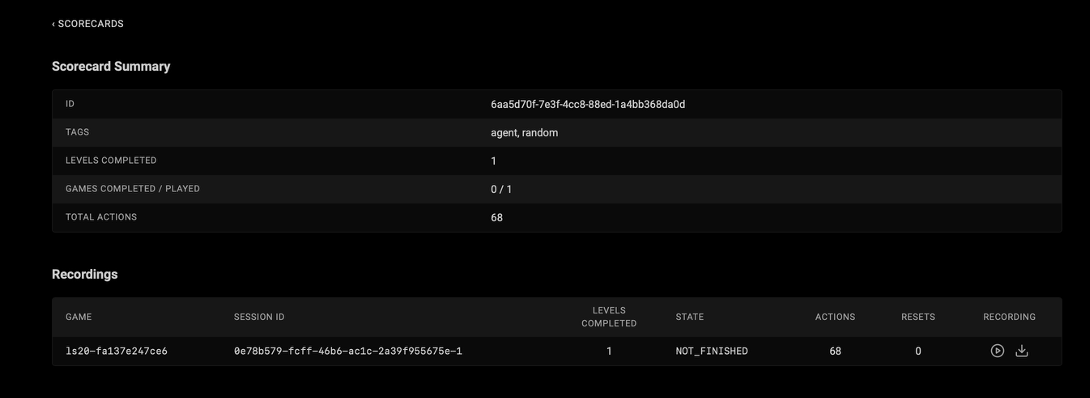

# 自前モデルで実行

## ARC-AGI-3設定

In [1]:
!pip install torch torchvision tqdm
!git clone https://github.com/arcprize/ARC-AGI-3-Agents.git
%cd /content/ARC-AGI-3-Agents
!pip install smolagents
%rm -rf agents/templates/langgraph_thinking

# langgraph 系 import を無効化
!sed -i \
  -e 's/^from \.templates\.langgraph_/## &/' \
  -e 's/^from \.templates\.llm_agents/## &/' \
  agents/__init__.py


Cloning into 'ARC-AGI-3-Agents'...
remote: Enumerating objects: 643, done.
remote: Counting objects: 100% (412/412), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 643 (delta 334), reused 255 (delta 255), pack-reused 231 (from 1)
Receiving objects: 100% (643/643), 408.22 KiB | 906.00 KiB/s, done.
Resolving deltas: 100% (431/431), done.
/content/ARC-AGI-3-Agents
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.4/148.4 kB 12.2 MB/s eta 0:00:00


In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__, device)

2.9.0+cu126 cuda


### API_KEY設定

In [3]:
import os
# ここにご自身のAPI_KEYを入れてください
os.environ['ARC_API_KEY'] = "xxxx"

### 自作モデル用ファイル作成

In [4]:
%cp agents/templates/random_agent.py agents/my_awesome_agent.py

In [5]:
import sys
sys.path.append("/content/ARC-AGI-3-Agents")


## モデル作成

### ファイルに保存

In [17]:
%%writefile agents/my_awesome_agent.py
"""CNN-based agent with online learning for ARC-AGI-3"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from pathlib import Path
from typing import Optional, Tuple
import time
from collections import deque
import hashlib

from .agent import Agent
from .structs import FrameData, GameAction, GameState

# Global timestamp to track last save time
_last_save_time = 0.0
_save_cooldown = 1.0

class ARCModel(nn.Module):
    """Simple MLP model for ARC-AGI-3 action + coord prediction"""

    def __init__(self, embedding_dim=16, hidden_dim=256):
        super().__init__()

        self.color_embedding = nn.Embedding(16, embedding_dim)
        flat_dim = 64 * 64 * embedding_dim

        # Encoding
        self.board_mlp = nn.Sequential(
            nn.Linear(flat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.info_mlp = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
        )

        # for action
        self.action_head = nn.Sequential(
            nn.Linear(hidden_dim + 32, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 8),  # 8 actions
        )

        # for ACTION6
        self.coord_head = nn.Sequential(
            nn.Linear(hidden_dim + 32, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, frame, score, state, action_id=None):
        B = frame.size(0)

        # (B, 64, 64) -> (B, 64, 64, E)
        x = self.color_embedding(frame)
        # -> (B, 64*64*E)
        x = x.view(B, -1)

        board_feat = self.board_mlp(x)

        info = torch.stack([score, state], dim=1).float()
        info_feat = self.info_mlp(info)

        h = torch.cat([board_feat, info_feat], dim=1)

        action_logits = self.action_head(h)
        coords = self.coord_head(h)
        # scaling
        coords = torch.sigmoid(coords) * 63.0

        return action_logits, coords


class MyAwesomeAgent(Agent):
    """CNN-based agent with online learning for ARC-AGI-3"""

    MAX_ACTIONS = 100  # Allow more actions for learning

    def __init__(
        self,
        *args,
        model_path: Optional[str] = None,
        learning_rate: float = 1e-4,
        save_dir: str = "models",
        epsilon: float = 0.5,  # Exploration rate for ε-greedy (50% random exploration)
        replay_batch_size: int = 32,  # Batch size for experience replay
        **kwargs
    ):
        super().__init__(*args, **kwargs)

        # Setup save directory first
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(exist_ok=True)

        # Exploration
        self.epsilon = epsilon


        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = ARCModel().to(self.device)

        # Optimizer
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)

        # Loss functions
        self.action_criterion = nn.CrossEntropyLoss()
        self.coord_criterion = nn.MSELoss()

        # Load pretrained model if provided (or shared model)
        if model_path is None:
            # Try to load shared model if exists
            shared_model_path = self.save_dir / "model_shared.pt"
            if shared_model_path.exists():
                model_path = str(shared_model_path)

        if model_path and Path(model_path).exists():
            checkpoint = torch.load(model_path, map_location=self.device)
            self.model.load_state_dict(checkpoint['model'])
            self.optimizer.load_state_dict(checkpoint['optimizer'])
            print(f"Loaded shared model from {model_path}")

        # Training mode
        self.model.train()

        # Tracking
        self.prev_frame: Optional[np.ndarray] = None
        self.prev_action_id: Optional[int] = None
        self.prev_coords: Optional[tuple[int, int]] = None
        self.step_count = 0
        self.total_reward = 0.0
        self.consecutive_no_change = 0  # Count consecutive frames with no change

        # Frame history for detecting revisits
        self.frame_history = []  # Store frame hashes
        self.frame_hash_set = set()  # For O(1) lookup

        # Metrics
        self.action_loss_history = []
        self.coord_loss_history = []
        self.reward_history = []

    def is_done(self, frames: list[FrameData], latest_frame: FrameData) -> bool:
        """Check if game is finished - only stop on WIN"""
        return latest_frame.state == GameState.WIN

    def frame_to_array(self, frame_data: list[list[list[int]]]) -> np.ndarray:
        """Convert frame data to numpy array

        Args:
            frame_data: [1, 64, 64] list of color IDs

        Returns:
            array: (64, 64) array of color IDs
        """
        if len(frame_data) > 0 and len(frame_data[0]) > 0:
            frame_array = np.array(frame_data[0], dtype=np.int64)  # (64, 64)
        else:
            frame_array = np.zeros((64, 64), dtype=np.int64)
        return frame_array

    def frame_to_tensor(self, frame_array: np.ndarray) -> torch.Tensor:
        """Convert frame array to tensor"""
        return torch.from_numpy(frame_array)

    def encode_state(self, state: GameState) -> int:
        """Encode game state as integer"""
        state_map = {
            GameState.NOT_PLAYED: 0,
            GameState.NOT_FINISHED: 1,
            GameState.WIN: 2,
            GameState.GAME_OVER: 3,
        }
        return state_map.get(state, 0)

    def _compute_frame_hash(self, frame: np.ndarray) -> str:
        """Compute hash of frame for revisit detection"""
        return hashlib.md5(frame.tobytes()).hexdigest()

    def compute_reward(
        self,
        latest_frame: FrameData,
        action_in_available: bool,
        frame_changed: bool,
        frame_revisited: bool = False
    ) -> float:
        """Compute reward based on action validity and frame change

        Args:
            latest_frame: Current frame data
            action_in_available: Whether action was in available_actions
            frame_changed: Whether frame changed after action
            frame_revisited: Whether we've seen this frame before

        Returns:
            reward: Float reward value (can be negative)
        """
        reward = 0.0

        # Penalty for not changing the frame (wasting actions)
        if not frame_changed:
            reward -= 2.0

        # Reward for choosing an action in available_actions
        if action_in_available:
            reward += 1.0

        # Big reward for changing the frame
        if frame_changed:
            reward += 5.0

        # Penalty for revisiting a previous frame state
        if frame_revisited:
            reward -= 3.0

        # Bonus for winning
        if latest_frame.state == GameState.WIN:
            reward += 10.0

        # Penalty for game over
        if latest_frame.state == GameState.GAME_OVER:
            reward -= 5.0

        return reward

    def learn(
        self,
        frame_tensor: torch.Tensor,
        score: float,
        state: int,
        action_id: int,
        coords: Optional[tuple[int, int]],
        reward: float
    ):
        frame_batch = frame_tensor.unsqueeze(0).to(self.device)  # (1, 64, 64)
        score_batch = torch.tensor([score], dtype=torch.float32).to(self.device)
        state_batch = torch.tensor([state], dtype=torch.float32).to(self.device)
        action_batch = torch.tensor([action_id], dtype=torch.long).to(self.device)

        # forwarding
        action_logits, pred_coords = self.model(
            frame_batch, score_batch, state_batch, action_batch
        )

        # Action loss
        action_target = torch.tensor([action_id], dtype=torch.long).to(self.device)
        action_loss = self.action_criterion(action_logits, action_target)

        # Coord loss
        coord_loss = torch.zeros(1, device=self.device)
        if coords is not None:
            coord_target = torch.tensor(
                [[coords[0], coords[1]]], dtype=torch.float32
            ).to(self.device)
            coord_loss = self.coord_criterion(pred_coords, coord_target)

        base_loss = action_loss + coord_loss

        if reward > 0:
            total_loss = base_loss
        else:
            total_loss = abs(reward) * base_loss

        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()

        # for log
        self.action_loss_history.append(action_loss.item())
        self.coord_loss_history.append(coord_loss.item())
        self.reward_history.append(reward)
        self.total_reward += reward

        if self.step_count % 10 == 0:
            print(
                f"Step {self.step_count}: Loss={total_loss.item():.4f} "
                f"(action={action_loss.item():.3f}, coord={coord_loss.item():.3f}), "
                f"Reward={reward:.2f}, Total={self.total_reward:.2f}, "
              )



    def choose_action(self, frames: list[FrameData], latest_frame: FrameData) -> GameAction:
        """Choose action using CNN model and learn from previous step"""

        current_frame_array = self.frame_to_array(latest_frame.frame)

        # Learn from previous step if available
        if self.prev_frame is not None and self.prev_action_id is not None:
            # Check if previous action was in available_actions
            prev_available_ids = [a.value for a in frames[-2].available_actions] if len(frames) >= 2 else []
            action_in_available = self.prev_action_id in prev_available_ids

            # Check if frame changed
            frame_changed = not np.array_equal(self.prev_frame, current_frame_array)

            # Check if frame was revisited
            current_frame_hash = self._compute_frame_hash(current_frame_array)
            frame_revisited = current_frame_hash in self.frame_hash_set

            # Add current frame to history
            if frame_changed:
                self.frame_history.append(current_frame_hash)
                self.frame_hash_set.add(current_frame_hash)

            # Debug: log frame change details
            diff_count = np.sum(self.prev_frame != current_frame_array)
            print(f"[DEBUG {self.game_id}] Step {self.step_count}: "
                  f"PrevAction={self.prev_action_id}, InAvailable={action_in_available}, "
                  f"FrameChanged={frame_changed}, Revisited={frame_revisited}, DiffPixels={diff_count}")

            # Compute reward
            reward = self.compute_reward(latest_frame, action_in_available, frame_changed, frame_revisited)

            # Get previous score/state from frames history
            prev_score = frames[-2].score if len(frames) >= 2 else 0
            prev_state = self.encode_state(frames[-2].state) if len(frames) >= 2 else 0

            # online training using a just prev state
            prev_frame_tensor = self.frame_to_tensor(self.prev_frame)
            self.learn(
                prev_frame_tensor,
                prev_score,
                prev_state,
                self.prev_action_id,
                self.prev_coords,
                reward
            )

        # Handle reset cases
        if latest_frame.state in [GameState.NOT_PLAYED, GameState.GAME_OVER]:
            action = GameAction.RESET
            action.reasoning = "Game not started or over - resetting"
            self.prev_frame = None
            self.prev_action_id = None
            self.prev_coords = None
            # Clear frame history on reset
            self.frame_history.clear()
            self.frame_hash_set.clear()
            return action

        # Prepare input
        frame_tensor = self.frame_to_tensor(current_frame_array).unsqueeze(0).to(self.device)  # (1, 64, 64)
        score_tensor = torch.tensor([latest_frame.score], dtype=torch.float32).to(self.device)
        state_tensor = torch.tensor([self.encode_state(latest_frame.state)], dtype=torch.float32).to(self.device)

        # Predict (without action_id, so next_frame_logits will be None)
        with torch.no_grad():
            action_logits, coords = self.model(frame_tensor, score_tensor, state_tensor)

        # Get action probabilities
        action_probs = torch.softmax(action_logits[0], dim=0).cpu().numpy()

        # Filter by available actions
        available_action_ids = [a.value for a in latest_frame.available_actions]

        # Debug: print available actions
        if self.step_count % 20 == 0:
            print(f"[{self.game_id}] Available actions: {available_action_ids}")

        if not available_action_ids:
            # No available actions, default to ACTION1
            action = GameAction.ACTION1
            action.reasoning = "No available actions specified"
            predicted_action_id = 1
        else:
            # ε-greedy action selection
            if np.random.random() < self.epsilon:
                # Random action from available actions
                predicted_action_id = np.random.choice(available_action_ids)
                action = GameAction.from_id(predicted_action_id)
                action.reasoning = f"Random exploration action {predicted_action_id}"
            else:
                # Use model prediction
                # Mask unavailable actions
                masked_probs = np.zeros_like(action_probs)
                for action_id in available_action_ids:
                    if action_id < len(action_probs):
                        masked_probs[action_id] = action_probs[action_id]

                # Normalize
                if masked_probs.sum() > 0:
                    masked_probs = masked_probs / masked_probs.sum()
                    predicted_action_id = int(np.argmax(masked_probs))
                else:
                    # Fallback to first available action
                    predicted_action_id = available_action_ids[0]

                # Convert to GameAction
                try:
                    action = GameAction.from_id(predicted_action_id)
                    action.reasoning = f"CNN predicted action {predicted_action_id} (prob: {action_probs[predicted_action_id]:.3f})"
                except ValueError:
                    # Fallback
                    predicted_action_id = available_action_ids[0]
                    action = GameAction.from_id(predicted_action_id)
                    action.reasoning = f"Fallback to action {predicted_action_id}"

        # Set data based on action type
        pred_coords = None
        if action.is_simple():
            action.set_data({"game_id": self.game_id})
            # reasoning is already set above
        elif action.is_complex():
            # Use predicted coordinates with ε-greedy exploration
            if np.random.random() < self.epsilon:
                # Random exploration
                x = np.random.randint(0, 64)
                y = np.random.randint(0, 64)
                action.reasoning = f"Random exploration ACTION6 at ({x}, {y})"
            else:
                # Use model prediction
                x = int(coords[0, 0].item())
                y = int(coords[0, 1].item())
                x = np.clip(x, 0, 63)
                y = np.clip(y, 0, 63)
                action.reasoning = f"CNN predicted ACTION6 at ({x}, {y})"

            pred_coords = (x, y)
            action.set_data({
                "game_id": self.game_id,
                "x": x,
                "y": y,
            })
            print(f"[ACTION6] {self.game_id}: clicking ({x}, {y})")

        # Store for next learning step
        self.prev_frame = current_frame_array.copy()
        self.prev_action_id = predicted_action_id
        self.prev_coords = pred_coords
        self.step_count += 1

        return action

    def cleanup(self, scorecard=None):
        """Save model on cleanup (shared across all games)"""
        global _last_save_time

        # Save model (shared across all games, not per-game)
        # Only save if we have actually taken steps AND sufficient time has passed
        # This prevents redundant saves from parallel game threads
        current_time = time.time()
        if self.step_count > 0 and (current_time - _last_save_time) > _save_cooldown:
            _last_save_time = current_time
            save_path = self.save_dir / "model_shared.pt"
            torch.save({
                'model': self.model.state_dict(),
                'optimizer': self.optimizer.state_dict(),
                'step': self.step_count,
                'total_reward': self.total_reward,
            }, save_path)
            print(f"[{self.game_id}] Saved shared model to {save_path}")

        # Save per-game metrics
        metrics_path = self.save_dir / f"metrics_{self.game_id}.txt"
        with open(metrics_path, 'w') as f:
            f.write(f"Game: {self.game_id}\n")
            f.write(f"Total steps: {self.step_count}\n")
            f.write(f"Total reward: {self.total_reward}\n")
            f.write(f"Avg action loss: {np.mean(self.action_loss_history) if self.action_loss_history else 0:.4f}\n")
            f.write(f"Avg coord loss: {np.mean(self.coord_loss_history) if self.coord_loss_history else 0:.4f}\n")
            f.write(f"Avg reward: {np.mean(self.reward_history) if self.reward_history else 0:.4f}\n")

        super().cleanup(scorecard)

Overwriting agents/my_awesome_agent.py


### __init__.py修正

In [15]:
from pathlib import Path

path = Path("agents/__init__.py")
text = path.read_text()

if "MyAwesomeAgent" not in text:
    patch = """
# === MyAwesomeAgent (Frozen NN Solver) ===

from .my_awesome_agent import MyAwesomeAgent

# ensure AVAILABLE_AGENTS exists
try:
    AVAILABLE_AGENTS
except NameError:
    AVAILABLE_AGENTS = {}

# lazy solver import (important!)
def _make_myawesomeagent(*args, **kwargs):
    return MyAwesomeAgent(*args, **kwargs)

AVAILABLE_AGENTS["myawesomeagent"] = _make_myawesomeagent

# extend __all__ safely
try:
    __all__ = list(__all__)
except NameError:
    __all__ = []

if "MyAwesomeAgent" not in __all__:
    __all__.append("MyAwesomeAgent")
"""

    path.write_text(text + patch)
    print("__init__.py patched safely")
else:
    print("__init__.py already contains MyAwesomeAgent")


__init__.py already contains MyAwesomeAgent


## 実行

In [18]:
# 最後に出力されるURLをクリックするとスコアをマイページで確認できる

# 全ゲームで実行する場合
# !python main.py --agent=myawesomeagent

# 特定のゲームで実行する場合
!python main.py --agent=myawesomeagent --game=ls20


https://three.arcprize.org/api/games
2026-01-05 07:39:10,100 | INFO | Game list: ['ls20-fa137e247ce6']
2026-01-05 07:39:10,868 | INFO | created new recording for ls20-fa137e247ce6.myawesomeagent into recordings/ls20-fa137e247ce6.myawesomeagent.c47400f6-036f-4173-9f2c-b3f30d47c4ef.recording.jsonl
Loaded shared model from models/model_shared.pt
2026-01-05 07:39:13,378 | INFO | ls20-fa137e247ce6 - RESET: count 0, score 0, avg fps 0.0)
[ls20-fa137e247ce6] Available actions: [1, 2, 3, 4]
2026-01-05 07:39:13,898 | INFO | ls20-fa137e247ce6 - ACTION3: count 1, score 0, avg fps 0.63)
[DEBUG ls20-fa137e247ce6] Step 1: PrevAction=3, InAvailable=True, FrameChanged=True, Revisited=False, DiffPixels=129
2026-01-05 07:39:14,451 | INFO | ls20-fa137e247ce6 - ACTION4: count 2, score 0, avg fps 0.94)
[DEBUG ls20-fa137e247ce6] Step 2: PrevAction=4, InAvailable=True, FrameChanged=True, Revisited=False, DiffPixels=129
2026-01-05 07:39:15,117 | INFO | ls20-fa137e247ce6 - ACTION2: count 3, score 0, avg fps 1.

#

# 以上

In [ ]:
#